# Loan Default Risk – Probability & Statistics Project

**Dataset:** `loan_applications.csv`  
**Records:** ~5000  
**Goal:** Explain key statistical concepts and apply Python-based statistical and probability analysis to evaluate loan default risk.

> Run the notebook from the `notebook` folder or change `DATA_PATH` if needed.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, norm
import math

df = pd.read_csv("loan_applications.csv")

print("Shape:", df.shape)
display(df.head())
print("\nMissing values:")
display(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (5000, 7)


,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
0,CUST00001,59,162972,46792,685,24,No
1,CUST00002,49,145992,85210,765,72,No
2,CUST00003,35,98059,55613,688,48,No
3,CUST00004,63,19881,38927,674,60,No
4,CUST00005,28,150702,5386,691,36,No



Missing values:


Customer_ID       0
Age               0
Income            0
Loan_Amount       0
Credit_Score      0
Loan_Term         0
Default_Status    0
dtype: int64


Duplicate rows: 0


## Part A – Theory Short Answers

### 1. Mean, Median, Mode
Mean is the average income. Median is the middle income after sorting. Mode is the most frequently occurring income value.

### 2. Standard Deviation vs Variance
Variance is the average squared distance from the mean. Standard deviation is the square root of variance and is expressed in the same unit as the loan amount.

### 3. Random Variable
A random variable assigns a numerical value to an outcome of a random experiment. Example: the loan amount selected from a randomly chosen application.

### 4. Conditional Probability
Conditional probability measures the chance of an event when another event is already known. Example: P(Default | Credit_Score < 600).

### 5. Bayes Theorem
Bayes theorem updates the probability of an event using new evidence: P(A|B) = P(B|A)P(A) / P(B). It can be used to update default risk after observing a customer's credit-score category.

### 6. Empirical vs Theoretical Probability
Empirical probability is calculated from observed data. Theoretical probability is based on a mathematical model or known assumptions.

### 7. Eigenvalues and Eigenvectors
For a square matrix A, an eigenvector v satisfies Av = λv, where λ is the eigenvalue. In data analysis they are useful in PCA to find important directions of variation.

## Part B – Step 1: Central Tendency & Dispersion

In [4]:
income = df["Income"]
loan = df["Loan_Amount"]

print("Mean Income:", income.mean())
print("Median Income:", income.median())
print("Mode(s) of Income:", income.mode().tolist())

print("\nLoan Amount Range:", loan.max() - loan.min())
print("Loan Amount Variance:", loan.var())
print("Loan Amount Standard Deviation:", loan.std())


Mean Income: 99495.3098
Median Income: 99872.0
Mode(s) of Income: [19881, 21262, 22042, 27491, 33916, 34766, 38389, 40419, 42502, 46036, 47086, 47092, 47545, 47709, 48782, 53739, 56346, 57220, 61169, 64015, 64418, 67112, 69012, 69428, 70335, 72460, 73798, 75196, 76560, 80894, 83792, 85560, 87351, 88199, 89947, 90255, 90572, 90833, 93791, 95924, 97360, 98720, 100806, 105858, 106074, 114870, 117273, 118211, 119505, 122186, 122504, 124311, 124471, 129023, 133074, 135399, 136920, 136972, 140013, 141099, 143342, 144083, 144244, 148193, 150659, 152275, 153639, 153797, 153994, 154694, 155521, 155605, 155844, 158749, 159041, 165531, 166725, 169388, 173086, 175255, 175699, 178371, 179771]

Loan Amount Range: 94985
Loan Amount Variance: 770847681.9239008
Loan Amount Standard Deviation: 27764.143817591437


## Step 2: Probability & Events

In [5]:
p_default = (df["Default_Status"] == "Yes").mean()
print("P(Default) =", p_default)

bins = [0, 599, 699, 799, 850]
labels = ["<600", "600-699", "700-799", "800-850"]
df["Credit_Range"] = pd.cut(df["Credit_Score"], bins=bins, labels=labels, include_lowest=True)

contingency = pd.crosstab(df["Credit_Range"], df["Default_Status"])
contingency["Total"] = contingency.sum(axis=1)
contingency["Default_Rate"] = contingency["Yes"] / contingency["Total"]

print("\nContingency table:")
display(contingency)

condition = df["Credit_Score"] < 600
p_conditional = ((condition) & (df["Default_Status"] == "Yes")).sum() / condition.sum()
print("P(Default | Credit_Score < 600) =", p_conditional)


P(Default) = 0.2462

Contingency table:


Default_Status,No,Yes,Total,Default_Rate
Credit_Range,,,,
<600,468,260,728,0.357143
600-699,1688,600,2288,0.262238
700-799,1351,341,1692,0.201537
800-850,262,30,292,0.102740


P(Default | Credit_Score < 600) = 0.35714285714285715


## Step 3: Distributions & Visualization

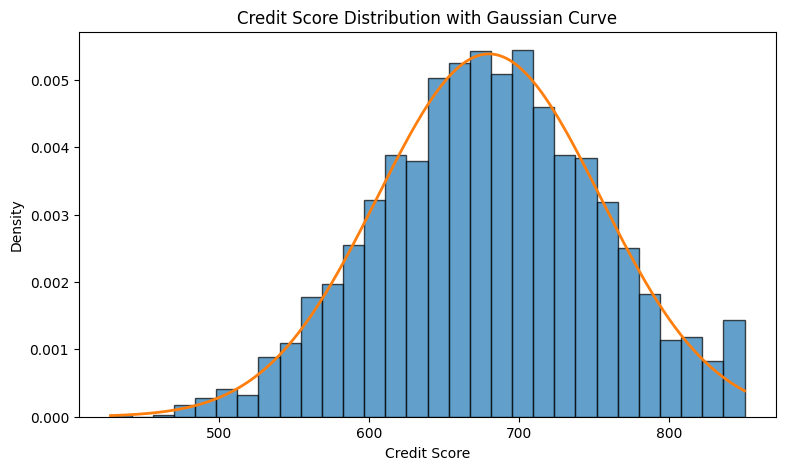

Loan Amount Skewness: 0.0039038896818881495
Loan Amount Excess Kurtosis: -1.2231371248316047


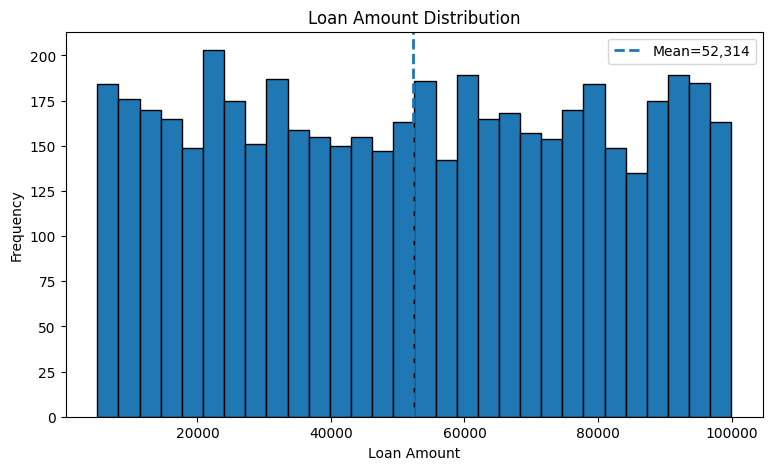

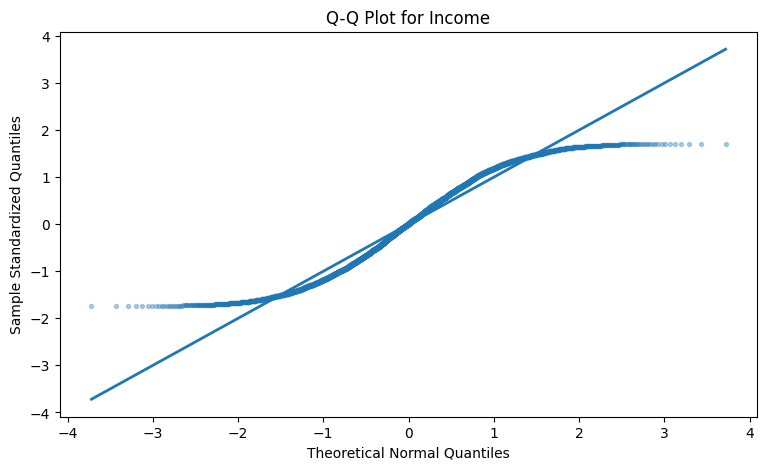

In [6]:
# Histogram of Credit Score + Gaussian curve
credit = df["Credit_Score"]
mu, sigma = credit.mean(), credit.std()
x = np.linspace(credit.min(), credit.max(), 400)

plt.figure(figsize=(9,5))
plt.hist(credit, bins=30, density=True, alpha=0.7, edgecolor="black")
plt.plot(x, norm.pdf(x, mu, sigma), linewidth=2)
plt.title("Credit Score Distribution with Gaussian Curve")
plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.show()

# Skewness and kurtosis of Loan Amount
loan = df["Loan_Amount"]
print("Loan Amount Skewness:", skew(loan, bias=False))
print("Loan Amount Excess Kurtosis:", kurtosis(loan, fisher=True, bias=False))

plt.figure(figsize=(9,5))
plt.hist(loan, bins=30, edgecolor="black")
plt.axvline(loan.mean(), linestyle="--", linewidth=2, label=f"Mean={loan.mean():,.0f}")
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Q-Q plot for Income
income = df["Income"].sort_values().to_numpy()
n = len(income)
probs = (np.arange(1, n+1)-0.5)/n
theoretical = norm.ppf(probs)
sample_z = (income - income.mean())/income.std()

plt.figure(figsize=(9,5))
plt.scatter(theoretical, sample_z, s=8, alpha=0.35)
lo = min(theoretical.min(), sample_z.min())
hi = max(theoretical.max(), sample_z.max())
plt.plot([lo,hi],[lo,hi], linewidth=2)
plt.title("Q-Q Plot for Income")
plt.xlabel("Theoretical Normal Quantiles")
plt.ylabel("Sample Standardized Quantiles")
plt.show()


## Step 4: Linear Algebra Application

In [7]:
first5 = df.loc[:4, ["Customer_ID", "Income", "Loan_Amount"]]
display(first5)

v1 = first5.iloc[0][["Income", "Loan_Amount"]].astype(float).to_numpy()
v2 = first5.iloc[1][["Income", "Loan_Amount"]].astype(float).to_numpy()

dot_product = np.dot(v1, v2)
norm_v1 = np.linalg.norm(v1)
norm_v2 = np.linalg.norm(v2)
cos_theta = dot_product / (norm_v1 * norm_v2)
angle_degrees = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

print("Customer 1 vector:", v1)
print("Customer 2 vector:", v2)
print("Dot product:", dot_product)
print("Norm of Customer 1:", norm_v1)
print("Norm of Customer 2:", norm_v2)
print("Angle between vectors (degrees):", angle_degrees)


,Customer_ID,Income,Loan_Amount
0,CUST00001,162972,46792
1,CUST00002,145992,85210
2,CUST00003,98059,55613
3,CUST00004,19881,38927
4,CUST00005,150702,5386


Customer 1 vector: [162972.  46792.]
Customer 2 vector: [145992.  85210.]
Dot product: 27779754544.0
Norm of Customer 1: 169556.37424762303
Norm of Customer 2: 169039.66446961495
Angle between vectors (degrees): 14.25082843655711


## Key Findings

1. About **24.62%** of applications in this generated dataset are marked as defaults.
2. Customers with **Credit Score < 600** have a default probability of about **35.71%**, higher than the overall default probability.
3. The default rate decreases as credit-score category increases: approximately **35.7% (<600), 26.2% (600–699), 20.2% (700–799), and 10.3% (800–850)**.
4. Loan Amount skewness is close to zero, indicating an approximately symmetric distribution.
5. The Q-Q plot helps visually compare the income distribution with a normal distribution.
